1. JE CHARGE MES FICHIERS ET JE LES INSPECTE 


In [14]:
# on importe la bibliotheque pandas pour la manipulation de données 
import pandas as pd 
# charger les données à partir du fichier train.csv 
df = pd.read_csv("train.csv")
# Voir les 5premieres lignes du dataframe
print(df.head())
# Voir les infos globales du dataframe 
print(df.isnull().sum())
# Voir les statistiques descriptives 
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

2. ANALYSE DES VARIABLES 

In [16]:
# Taux de survie global 
print(df["Survived"].value_counts(normalize=True))

# Survie par classe 
print(df.groupby("Sex")["Survived"].mean())

# Survie par sexe
print(df.groupby("Sex")["Survived"].mean())

# Survie par classe
print(df.groupby("Pclass")["Survived"].mean())

# survie par classe et sexe
df.groupby(["Sex", "Pclass"])["Survived"].mean()

# survie par classe et groupe d'age
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 19, 59, 100],
                labels=["Child", "Teen", "Adult", "Senior"])

df.groupby(["AgeGroup", "Pclass"])["Survived"].mean()

# survie par classe et embarquation
df.groupby(["Embarked", "Pclass"])["Survived"].mean()


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


C:\Users\delim\AppData\Local\Temp\ipykernel_15140\76116490.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["AgeGroup", "Pclass"])["Survived"].mean()


Embarked  Pclass
C         1         0.694118
          2         0.529412
          3         0.378788
Q         1         0.500000
          2         0.666667
          3         0.375000
S         1         0.582677
          2         0.463415
          3         0.189802
Name: Survived, dtype: float64

3.VISUALISATION DES DONNEES


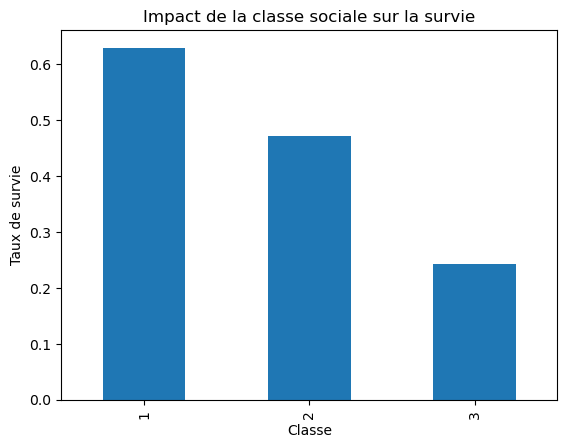

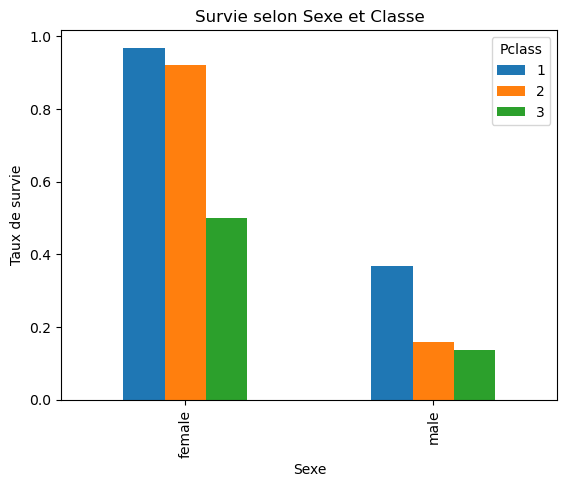

C:\Users\delim\AppData\Local\Temp\ipykernel_15140\2654090821.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")


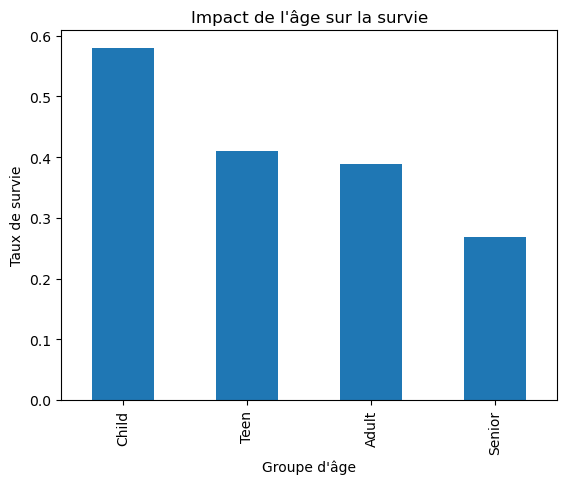

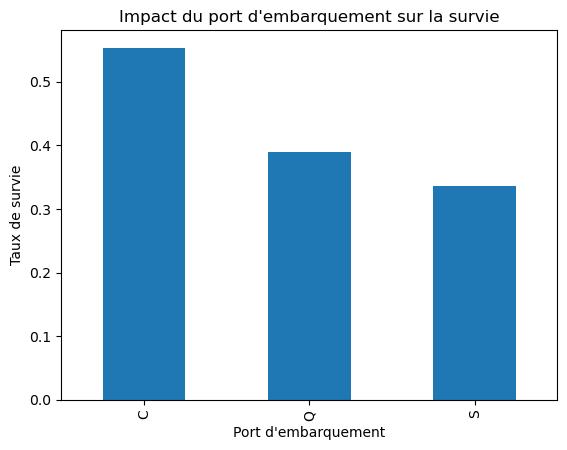

In [19]:
import matplotlib.pyplot as plt

#  1. Impact de la classe sociale sur la survie
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Impact de la classe sociale sur la survie")
plt.ylabel("Taux de survie")
plt.xlabel("Classe")
plt.show()

#  2. Interaction Sexe + Classe
df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().plot(kind="bar")
plt.title("Survie selon Sexe et Classe")
plt.ylabel("Taux de survie")
plt.xlabel("Sexe")
plt.show()

#  3. Impact de l’âge (groupé)
df.groupby("AgeGroup")["Survived"].mean().plot(kind="bar")
plt.title("Impact de l'âge sur la survie")
plt.ylabel("Taux de survie")
plt.xlabel("Groupe d'âge")
plt.show()

#  4. Impact du port d’embarquement
df.groupby("Embarked")["Survived"].mean().plot(kind="bar")
plt.title("Impact du port d'embarquement sur la survie")
plt.ylabel("Taux de survie")
plt.xlabel("Port d'embarquement")
plt.show()

Conclusion de l’analyse exploratoire (EDA)

Après analyse du dataset Titanic, plusieurs insights importants ont été identifiés.

1. Sexe
Les femmes ont un taux de survie beaucoup plus élevé (environ 74 %).
Les hommes ont un taux de survie très faible (environ 19 %).

Interprétation :
Le sexe est la variable la plus influente dans la prédiction de la survie.

2. Classe sociale (Pclass)
Classe 1 : taux de survie élevé
Classe 3 : taux de survie très faible

Interprétation :
La classe sociale a un impact majeur sur la probabilité de survie.

3. Interaction Sexe + Classe
Femme en classe 1 : survie quasi certaine (environ 96 %)
Homme en classe 3 : survie très faible (environ 13 %)

Interprétation :
Les interactions entre variables sont essentielles. Le modèle devra capturer ces effets combinés.

4. Port d’embarquement (Embarked)
Influence indirecte observée via la distribution des classes sociales.

Interprétation :
Variable secondaire, mais qui peut apporter de l’information utile au modèle.

5. Âge
Les enfants ont une probabilité de survie plus élevée.

Interprétation :
Variable importante, nécessitant probablement une transformation (ex : regroupement en classes d’âge).

Conclusion générale

La survie des passagers dépend principalement des facteurs suivants :

Le sexe
La classe sociale
Les interactions entre variables

Ces variables devront être prioritaires lors de la construction du modèle de Machine Learning.